# Medical Insurance Charges: EDA and Prediction

**Goal:** understand what drives individual medical insurance charges and build a model that predicts them.

**Dataset:** 1,338 policyholders with `age`, `sex`, `bmi`, `children`, `smoker`, `region`, and the target `charges` (USD).

**Approach:** EDA, cleaning, feature engineering, a leak-free train/test split, model comparison with cross-validation, and business recommendations.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

## 1. Load and inspect

In [2]:
df = pd.read_csv('../data/insurance.csv')
print(df.shape)
df.head()

(1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [4]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [5]:
print('Missing values:', df.isnull().sum().sum())
print('Duplicate rows:', df.duplicated().sum())

Missing values: 0
Duplicate rows: 1


The data has no missing values and one duplicate row, which is dropped in the cleaning step.

## 2. Exploratory data analysis

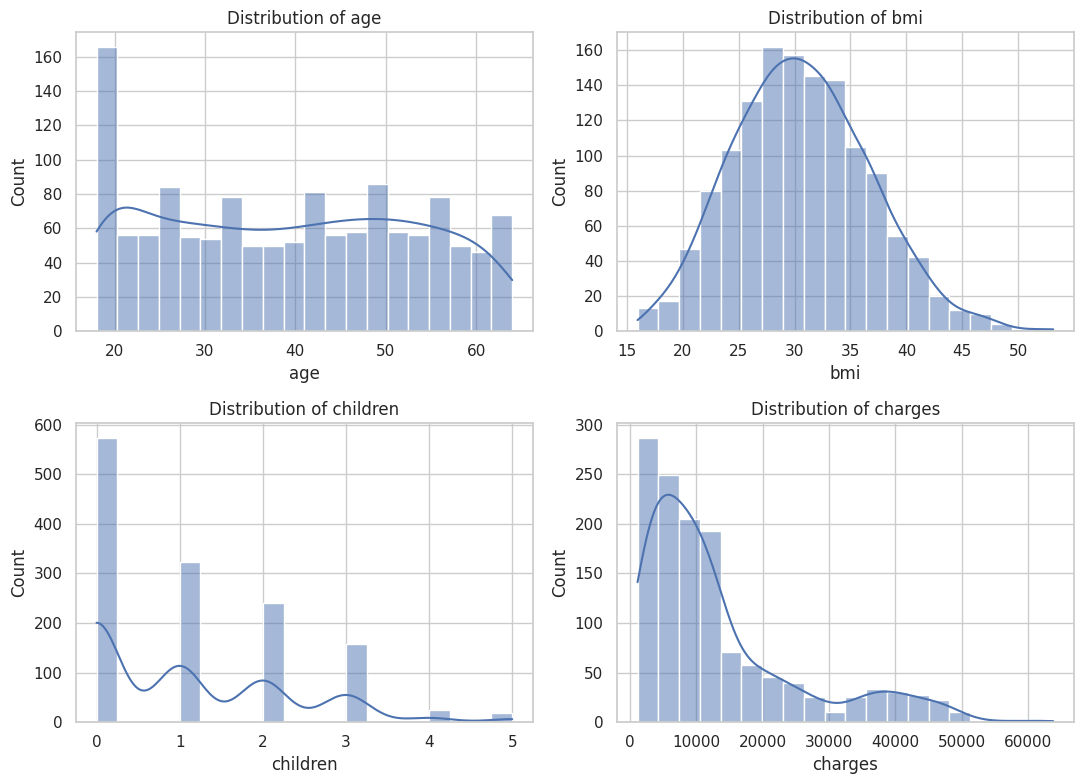

In [6]:
numeric_columns = ['age', 'bmi', 'children', 'charges']
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, col in zip(axes.ravel(), numeric_columns):
    sns.histplot(df[col], kde=True, bins=20, ax=ax)
    ax.set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

`charges` is strongly right-skewed: most people pay under about $15k, with a long tail of very expensive cases. BMI looks roughly normal.

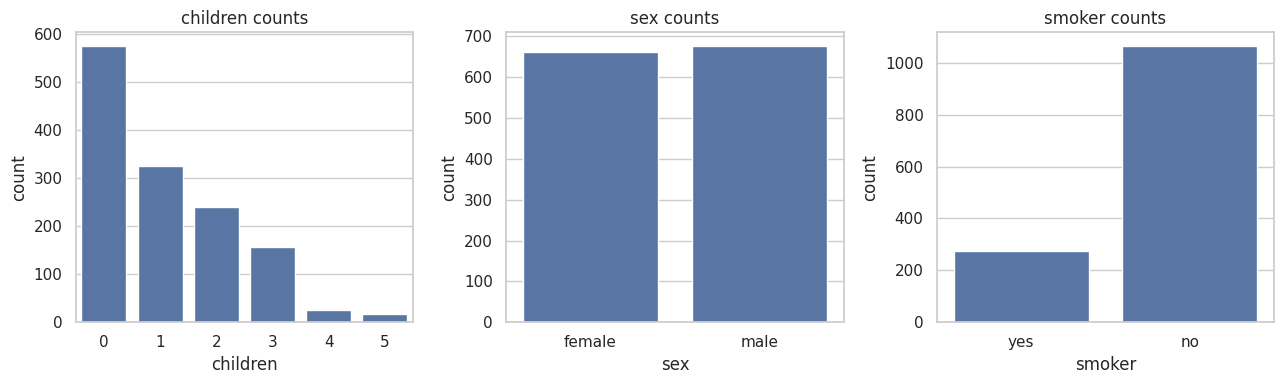

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col in zip(axes, ['children', 'sex', 'smoker']):
    sns.countplot(x=df[col], ax=ax)
    ax.set_title(f'{col} counts')
plt.tight_layout()
plt.show()

Only about 20% of policyholders are smokers, and the sexes are almost evenly split.

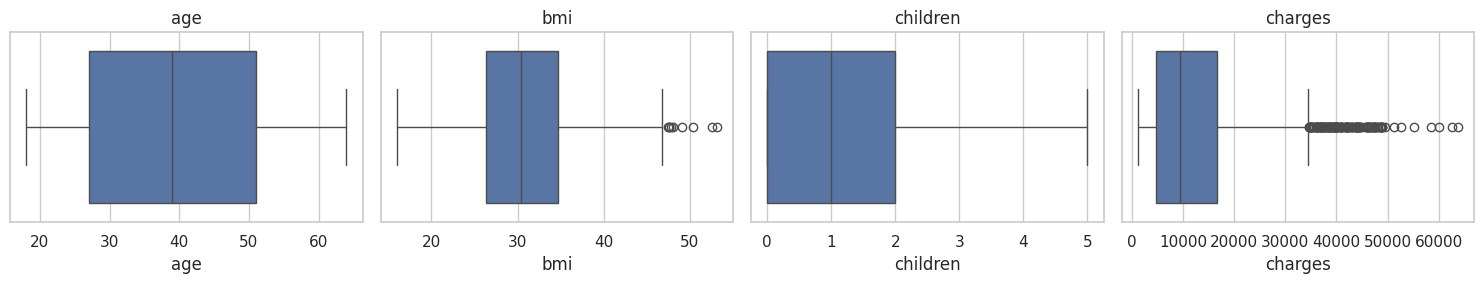

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3))
for ax, col in zip(axes, numeric_columns):
    sns.boxplot(x=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

BMI and charges both show high-end outliers. They are real policyholders rather than data errors, so they are kept.

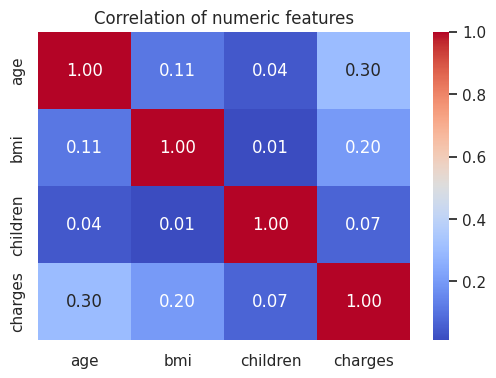

In [9]:
plt.figure(figsize=(6, 4))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation of numeric features')
plt.show()

           mean   median  count
smoker                         
no       8434.0   7345.0   1064
yes     32050.0  34456.0    274


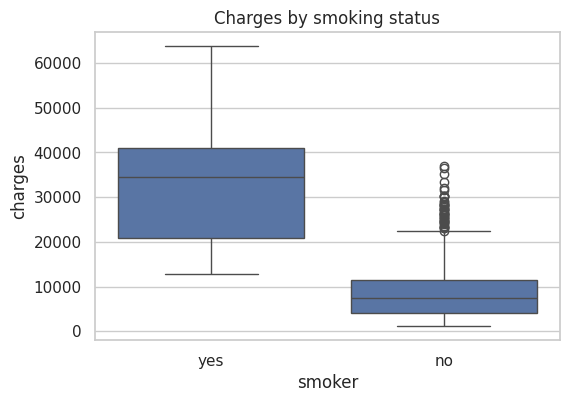

In [10]:
print(df.groupby('smoker')['charges'].agg(['mean', 'median', 'count']).round(0))

plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='smoker', y='charges')
plt.title('Charges by smoking status')
plt.show()

**Smoking is the clearest signal in the data.** Smokers pay about $32k on average against about $8k for non-smokers, nearly four times as much.

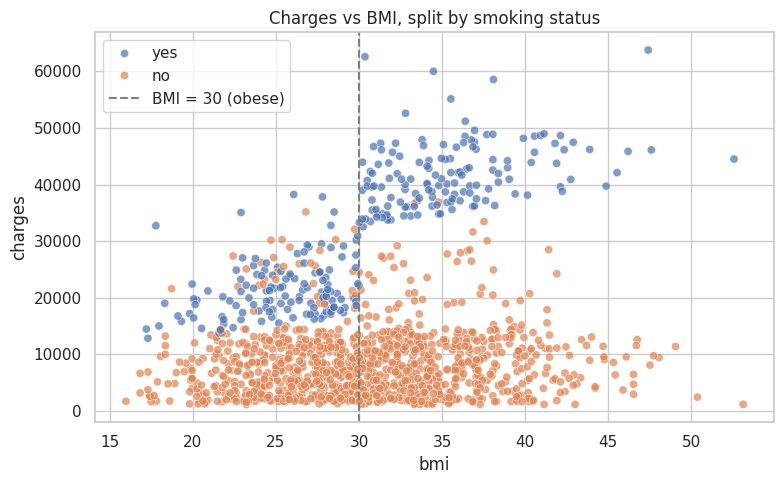

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker', alpha=0.7, ax=ax)
ax.axvline(30, color='grey', linestyle='--', label='BMI = 30 (obese)')
ax.set_title('Charges vs BMI, split by smoking status')
ax.legend()
plt.tight_layout()
plt.savefig('../images/charges_by_smoker_bmi.png', dpi=150)
plt.show()

The scatter shows an **interaction**. For non-smokers, charges barely change with BMI. For smokers, charges jump once BMI passes about 30. A model that only adds the effects of BMI and smoking together will miss this, so it is built in as a feature below.

## 3. Cleaning and feature engineering

In [12]:
df_clean = df.drop_duplicates().copy()
print(df_clean.shape)

# Binary encodings
df_clean['is_female'] = (df_clean['sex'] == 'female').astype(int)
df_clean['is_smoker'] = (df_clean['smoker'] == 'yes').astype(int)

# BMI category built from the ORIGINAL (unrounded) BMI
df_clean['bmi_category'] = pd.cut(
    df_clean['bmi'],
    bins=[0, 18.5, 25, 30, np.inf],
    labels=['Underweight', 'Normal', 'Overweight', 'Obese'],
    right=False,
)
df_clean['is_obese'] = (df_clean['bmi'] >= 30).astype(int)

# Interaction suggested by the scatter plot
df_clean['smoker_obese'] = df_clean['is_smoker'] * df_clean['is_obese']

print(df_clean.groupby(['is_smoker', 'is_obese'])['charges'].agg(['mean', 'count']).round(0))

(1337, 7)
                       mean  count
is_smoker is_obese                
0         0          7977.0    502
          1          8856.0    561
1         0         21363.0    129
          1         41558.0    145


**Note on fixing an earlier bug:** converting the whole frame with `.astype(int)` silently truncates `bmi` and `charges` to whole numbers (27.9 becomes 27), which also shifts people across BMI category boundaries. Here only the binary columns are converted, so continuous values stay exact.

**The interaction is large.** Smokers with BMI of 30 or more average about $41.6k. Smokers below 30 average about $21.4k, and non-smokers average roughly $8k to $9k whatever their BMI.

In [13]:
features = ['age', 'bmi', 'children', 'is_female', 'is_smoker', 'region', 'is_obese', 'smoker_obese']
X = pd.get_dummies(df_clean[features], columns=['region'], drop_first=True).astype(float)
y = df_clean['charges']
X.head()

,age,bmi,children,is_female,is_smoker,is_obese,smoker_obese,region_northwest,region_southeast,region_southwest
0,19.0,27.900,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0
1,18.0,33.770,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,28.0,33.000,3.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3,33.0,22.705,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,32.0,28.880,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


With only 8 base features and a regression target, all features are kept and left for the models to weight. The earlier approach of discarding features by chi-square p-value on charges quartiles is dropped: binning the target throws away information, and it would have removed features that matter for prediction.

## 4. Train/test split and models

The split happens **before** any scaling. The scaler lives inside the pipeline, so it is fitted on training data only and there is no leakage.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(X_train.shape, X_test.shape)

scale_cols = ['age', 'bmi', 'children']
def make_scaler():
    return ColumnTransformer([('scale', StandardScaler(), scale_cols)], remainder='passthrough')

models = {
    'Linear Regression': Pipeline([('prep', make_scaler()), ('model', LinearRegression())]),
    'Linear Regression (log target)': TransformedTargetRegressor(
        regressor=Pipeline([('prep', make_scaler()), ('model', LinearRegression())]),
        func=np.log, inverse_func=np.exp),
    'Random Forest': RandomForestRegressor(n_estimators=300, min_samples_leaf=5, random_state=RANDOM_STATE),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, max_depth=3,
                                                   learning_rate=0.05, random_state=RANDOM_STATE),
}

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
rows = []
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    cv = cross_val_score(model, X, y, cv=kf, scoring='r2')
    rows.append({
        'Model': name,
        'Test R2': r2_score(y_test, pred),
        'Test RMSE': mean_squared_error(y_test, pred) ** 0.5,
        'Test MAE': mean_absolute_error(y_test, pred),
        'CV R2 (mean)': cv.mean(),
        'CV R2 (std)': cv.std(),
    })
results = pd.DataFrame(rows).set_index('Model').round(3)
results

(1069, 10) (268, 10)


,Test R2,Test RMSE,Test MAE,CV R2 (mean),CV R2 (std)
Model,,,,,
Linear Regression,0.907,4142.307,2368.757,0.859,0.030
Linear Regression (log target),0.674,7743.443,3844.866,0.443,0.224
Random Forest,0.898,4335.248,2451.077,0.852,0.026
Gradient Boosting,0.904,4205.593,2457.472,0.856,0.027


**Findings:**
- Plain linear regression, the simplest model, performs as well as the tree ensembles (test R² of about 0.91, typical error around $2.4k MAE). Most of the predictive power came from the interaction feature, not from model complexity.
- Log-transforming the target did **not** help here and made cross-validation unstable. It is kept in the table as a documented negative result.
- Cross-validated R² (about 0.86) is lower than the single test split (about 0.90), which is a useful reminder not to quote one lucky split.

In [15]:
# Does the interaction feature really matter? Re-fit linear regression without it.
base_cols = [c for c in X.columns if c not in ('is_obese', 'smoker_obese')]
lr_base = Pipeline([('prep', make_scaler()), ('model', LinearRegression())]).fit(X_train[base_cols], y_train)
print('Linear Regression R2 WITHOUT interaction:', round(r2_score(y_test, lr_base.predict(X_test[base_cols])), 3))
print('Linear Regression R2 WITH interaction:   ', round(results.loc['Linear Regression', 'Test R2'], 3))

Linear Regression R2 WITHOUT interaction: 0.807
Linear Regression R2 WITH interaction:    0.907


Adding the smoker × obese interaction lifts linear regression R² from about 0.81 to about 0.91, the largest single improvement in the project.

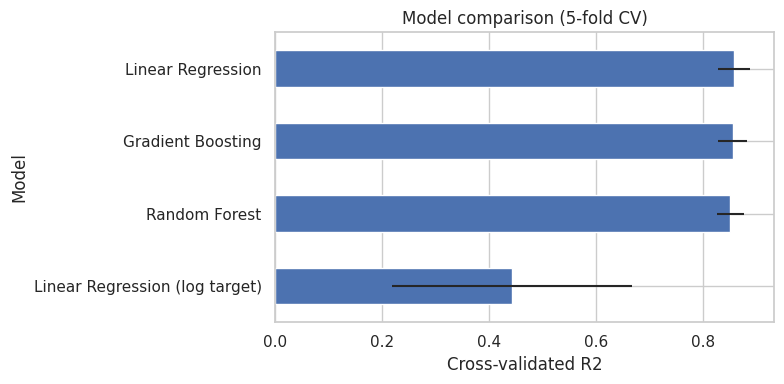

In [16]:
fig, ax = plt.subplots(figsize=(8, 4))
results['CV R2 (mean)'].sort_values().plot.barh(ax=ax, xerr=results['CV R2 (std)'].reindex(results['CV R2 (mean)'].sort_values().index))
ax.set_xlabel('Cross-validated R2')
ax.set_title('Model comparison (5-fold CV)')
plt.tight_layout()
plt.savefig('../images/model_comparison.png', dpi=150)
plt.show()

## 5. What drives the predictions?

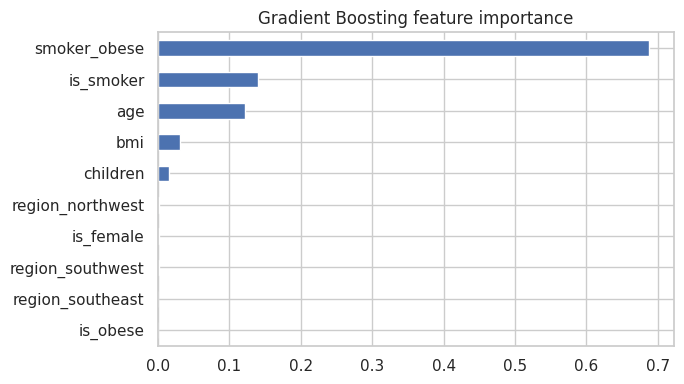

In [17]:
gb = models['Gradient Boosting']
imp = pd.Series(gb.feature_importances_, index=X.columns).sort_values()

fig, ax = plt.subplots(figsize=(7, 4))
imp.plot.barh(ax=ax)
ax.set_title('Gradient Boosting feature importance')
plt.tight_layout()
plt.savefig('../images/feature_importance.png', dpi=150)
plt.show()

Smoking status (directly and through the smoker × obese interaction) dominates, followed by age. BMI matters mostly in combination with smoking. Sex, region, and number of children contribute almost nothing. Because `smoker_obese` and `is_smoker` are correlated, importance is split between them, so read them together.

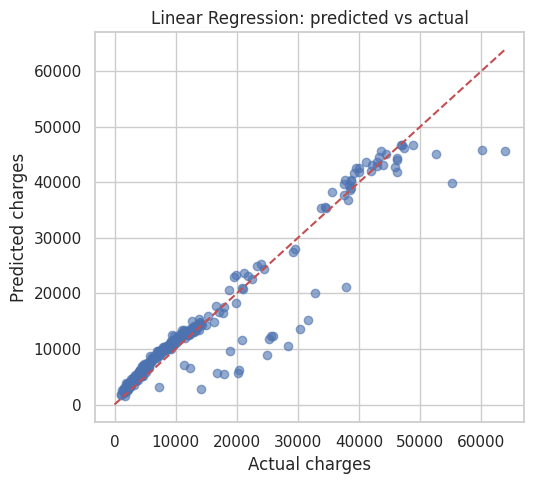

In [18]:
best = models['Linear Regression']
pred = best.predict(X_test)
fig, ax = plt.subplots(figsize=(5.5, 5))
ax.scatter(y_test, pred, alpha=0.6)
lims = [0, max(y_test.max(), pred.max())]
ax.plot(lims, lims, 'r--')
ax.set_xlabel('Actual charges')
ax.set_ylabel('Predicted charges')
ax.set_title('Linear Regression: predicted vs actual')
plt.tight_layout()
plt.show()

Predictions track actual charges well overall. The largest errors are all underestimates of unusually expensive cases, including several non-smokers with charges of $20k to $30k that the model cannot explain from the available features (see Limitations).

## 6. Summary

- **Data:** 1,337 policyholders after dropping one duplicate, with no missing values.
- **Biggest driver:** smoking. Smokers pay about 3.8x more on average ($32.1k vs $8.4k).
- **Key interaction:** smokers with BMI of 30 or more average about $41.6k, roughly five times the $8.0k of non-smokers with a healthy BMI. BMI barely matters for non-smokers.
- **Age** is the second driver; charges rise steadily with age.
- **Sex, region, and children** have little effect.
- **Best model:** linear regression with the smoker × obese interaction, test R² about 0.91 and MAE about $2.4k. Random forest and gradient boosting perform about the same, so the simpler, more interpretable model is preferred.

## 7. Recommendations

1. **Make smoking status the primary pricing factor.** It outweighs every other variable in the data.
2. **Treat smokers with BMI of 30 or more as the highest-risk segment.** They have the highest average charges in the data, so they are the group to review for pricing and care management.
3. **Target prevention spend where it pays off.** Smoking-cessation programs probably offer the largest per-person savings, and weight-management support matters most for smokers.
4. **Do not overweight region or sex** in pricing models. The data shows little signal, and relying on them adds fairness and regulatory risk without improving accuracy.
5. **Prefer an interpretable model.** A regression with a well-chosen interaction matches the ensembles and is easier to explain to underwriters and regulators.

## 8. Limitations and next steps

- Only 1,338 rows and no medical history, claims history, or income. Real pricing needs far richer data.
- This is a widely used public dataset and appears simplified or synthetic, so results may not transfer to real portfolios.
- The biggest errors are expensive cases the model underestimates, including some non-smokers with $20k to $30k charges. This suggests missing variables such as chronic conditions.
- Next steps: hyperparameter tuning, a smoker × age interaction, quantile or Gamma-GLM models suited to skewed costs, and a simple Streamlit app for predictions.